# Customer Segmentation Analysis

## Oasis Infobyte Internship — Data Analytics, Level 1, Task 2

### Objective
Apply customer segmentation techniques to identify groups of customers based on their purchasing behaviour. Use Recency, Frequency, and Monetary (RFM) analysis with K-Means clustering to support targeted marketing strategies.

### Tools Used
Python, Pandas, NumPy, Matplotlib, Seaborn, and Scikit-learn.

In [51]:
# Importing libraries
import os
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [52]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")

Libraries imported successfully.


In [53]:
# Upload and load the dataset
from google.colab import files
uploaded = files.upload()

Saving Online Retail.csv to Online Retail (1).csv


In [54]:
df = pd.read_csv("Online Retail.csv", encoding="ISO-8859-1")
print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [55]:
# Inspect the dataset
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()

print("\nFirst five rows:")
display(df.head())

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Dataset shape: (541909, 8)

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

First five row

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom



Missing values:


,0
CustomerID,135080
Description,1454
StockCode,0
InvoiceNo,0
Quantity,0
InvoiceDate,0
UnitPrice,0
Country,0



Duplicate rows: 5268

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,31-10-2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Initial Dataset Inspection

The Online Retail dataset contains transaction-level information, including invoice numbers, product descriptions, quantities, invoice dates, unit prices, customer IDs, and countries.

Customer IDs are essential for customer-level segmentation. Records without a customer ID cannot be reliably assigned to a customer segment and will be excluded from the RFM analysis.

Duplicate transactions, cancelled invoices, negative quantities, and invalid prices will also be examined before calculating purchasing behaviour.

In [56]:
# Clean the data
df.columns = df.columns.str.strip()

required_columns = [
    "InvoiceNo",
    "InvoiceDate",
    "Quantity",
    "UnitPrice",
    "CustomerID"
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"], errors="coerce"
)
df["CustomerID"] = df["CustomerID"].astype("string").str.strip()
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["UnitPrice"] = pd.to_numeric(df["UnitPrice"], errors="coerce")
print("Data types standardized.")
display(df.dtypes)

Data types standardized.


,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,string[python]
Country,object


In [57]:
initial_rows = len(df)
duplicate_count = int(df.duplicated().sum())
df = df.drop_duplicates().copy()

print("Rows before duplicate removal:", initial_rows)
print("Duplicate rows removed:", duplicate_count)
print("Rows after duplicate removal:", len(df))

Rows before duplicate removal: 541909
Duplicate rows removed: 5269
Rows after duplicate removal: 536640


In [58]:
# Handle missing and invalid values
rows_before_cleaning = len(df)

# Remove rows without essential transaction fields
df = df.dropna(
    subset=["InvoiceNo","InvoiceDate","Quantity","UnitPrice","CustomerID"]
).copy()

# Remove empty customer IDs
df = df[df["CustomerID"].str.strip() != ""].copy()

# Exclude cancelled invoices.
# Online Retail cancellation invoice numbers commonly begin with C.
invoice_text = df["InvoiceNo"].astype(str).str.strip()
cancelled_mask = invoice_text.str.upper().str.startswith("C")
cancelled_rows = int(cancelled_mask.sum())
df = df[~cancelled_mask].copy()

# Retain positive sales transactions for customer spending analysis.
# Negative quantities may represent returns, and zero/negative prices
# should not contribute to positive sales-value calculations.
invalid_quantity_rows = int((df["Quantity"] <= 0).sum())
invalid_price_rows = int((df["UnitPrice"] <= 0).sum())

df = df[
    (df["Quantity"] > 0) &
    (df["UnitPrice"] > 0)
].copy()
df["CustomerID"] = df["CustomerID"].astype(str)

print("Rows before cleaning:", rows_before_cleaning)
print("Cancellation rows excluded:", cancelled_rows)
print("Rows with non-positive quantities removed:", invalid_quantity_rows)
print("Rows with non-positive prices removed:", invalid_price_rows)
print("Rows remaining:", len(df))
print("Missing values remaining in required columns:")
display(df[required_columns].isnull().sum())

Rows before cleaning: 536640
Cancellation rows excluded: 4111
Rows with non-positive quantities removed: 0
Rows with non-positive prices removed: 18
Rows remaining: 166363
Missing values remaining in required columns:


,0
InvoiceNo,0
InvoiceDate,0
Quantity,0
UnitPrice,0
CustomerID,0


## Data Cleaning Decisions

The cleaning process removes duplicate rows, records missing essential transaction information, cancelled invoices, and transactions with non-positive quantities or unit prices.

These decisions help focus the analysis on identifiable customers and positive purchase transactions. However, returns and cancellations may contain useful business information; they are excluded from this positive-purchase segmentation rather than being treated as ordinary purchases.

The final number of retained rows is reported by the notebook so that the cleaning process is transparent and reproducible.

In [59]:
# Calculate transaction revenue
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print("Total positive-purchase revenue:", round(df["Revenue"].sum(), 2))
print("Unique customers:", df["CustomerID"].nunique())
print("Unique invoices:", df["InvoiceNo"].nunique())

display(df.head())

Total positive-purchase revenue: 3865463.08
Unique customers: 2997
Unique invoices: 7961


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34


In [60]:
# Build the RFM table
# Reference date is one day after the last transaction date.
reference_date = df["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    LastPurchaseDate=("InvoiceDate", "max"),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
)

rfm["Recency"] = (reference_date - rfm["LastPurchaseDate"]).dt.days
rfm = rfm[["Recency", "Frequency", "Monetary"]].copy()

# Basic customer-level measures
rfm["AveragePurchaseValue"] = (rfm["Monetary"] / rfm["Frequency"])

# Historical spend proxy, not a prediction of future lifetime value
rfm["HistoricalCustomerValue"] = rfm["Monetary"]

print("Reference date:", reference_date.date())
print("Number of customers:", len(rfm))

display(rfm.head(10))

Reference date: 2011-12-11
Number of customers: 2997


,Recency,Frequency,Monetary,AveragePurchaseValue,HistoricalCustomerValue
CustomerID,,,,,
12347.0,95,5,2540.29,508.058000,2540.29
12348.0,220,1,367.00,367.000000,367.00
12350.0,311,1,334.40,334.400000,334.40
12352.0,274,3,1296.38,432.126667,1296.38
12355.0,96,1,459.40,459.400000,459.40
12356.0,128,1,481.46,481.460000,481.46
12357.0,182,1,6207.67,6207.670000,6207.67
12358.0,3,2,1168.06,584.030000,1168.06
12359.0,9,3,3495.73,1165.243333,3495.73


In [61]:
# Descriptive statistics for customer behaviour
print("RFM descriptive statistics:")
display(rfm[["Recency", "Frequency", "Monetary"]].describe().T)

print("\nAverage purchase value and historical customer value:")
display(
    rfm[["AveragePurchaseValue", "HistoricalCustomerValue"]].describe().T
)

print("\nNumber of customers with repeat purchases:")
print((rfm["Frequency"] > 1).sum())

print("\nPercentage of customers with repeat purchases:")
print(round((rfm["Frequency"] > 1).mean() * 100, 2), "%")

RFM descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Recency,2997.0,154.419086,140.146976,0.0,39.00,124.00,218.00,697.0
Frequency,2997.0,2.656323,4.008919,1.0,1.00,2.00,3.00,106.0
Monetary,2997.0,1289.777471,5273.011876,5.9,244.41,466.29,1064.28,168469.6



Average purchase value and historical customer value:


,count,mean,std,min,25%,50%,75%,max
AveragePurchaseValue,2997.0,445.824304,3117.823412,5.9,173.70,293.96,427.80,168469.6
HistoricalCustomerValue,2997.0,1289.777471,5273.011876,5.9,244.41,466.29,1064.28,168469.6



Number of customers with repeat purchases:
1534

Percentage of customers with repeat purchases:
51.18 %


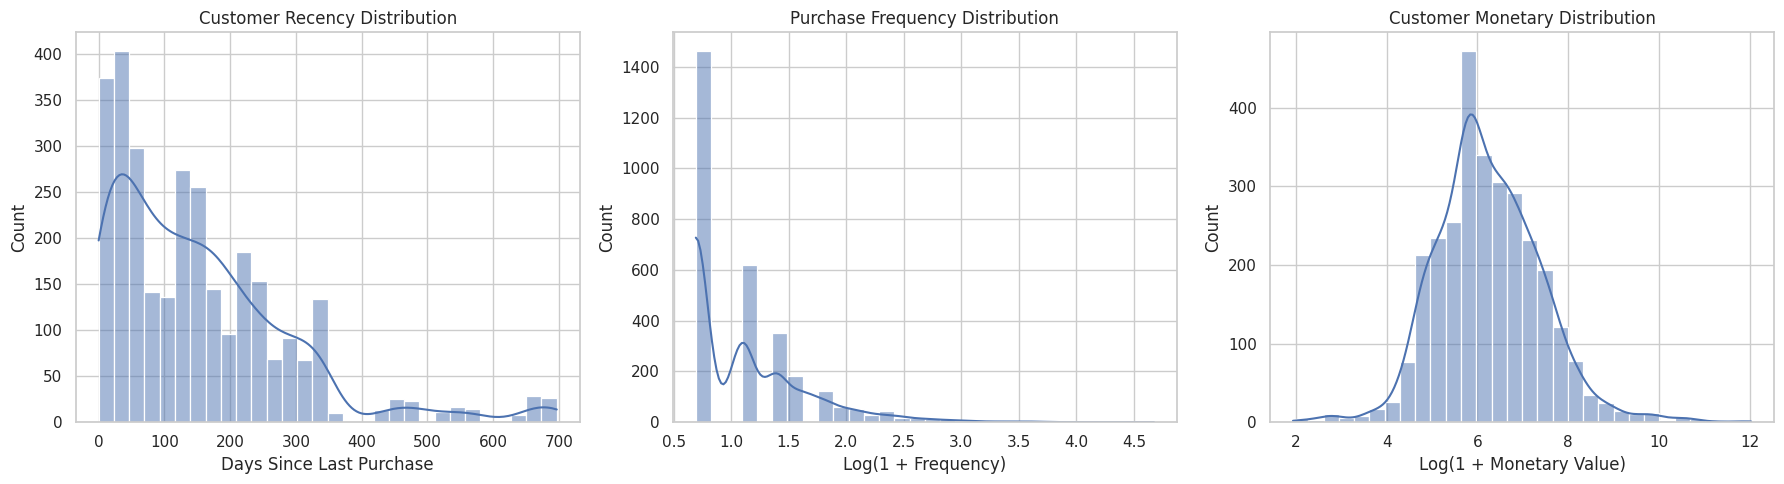

In [62]:
# Visualize RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Customer Recency Distribution")
axes[0].set_xlabel("Days Since Last Purchase")

sns.histplot(
    np.log1p(rfm["Frequency"]),
    bins=30,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Purchase Frequency Distribution")
axes[1].set_xlabel("Log(1 + Frequency)")

sns.histplot(
    np.log1p(rfm["Monetary"]),
    bins=30,
    kde=True,
    ax=axes[2]
)
axes[2].set_title("Customer Monetary Distribution")
axes[2].set_xlabel("Log(1 + Monetary Value)")

plt.tight_layout()
plt.show()

## Observation — RFM Analysis

The RFM table summarizes customer purchasing behaviour using recency, purchase frequency, and total monetary value.

Customers with lower recency values have purchased more recently. Customers with higher frequency values have purchased more often, while customers with higher monetary values have contributed more historical revenue.

The distribution plots help identify skewness and differences in customer behaviour. Log transformations will be used for the clustering features to reduce the influence of extremely large frequency and spending values.

In [63]:
# Prepare features for K-Means
features = rfm[["Recency", "Frequency", "Monetary"]].copy()

# Log-transform positive, right-skewed features.
# Recency is kept in days; Frequency and Monetary are log-transformed.
features["Frequency"] = np.log1p(features["Frequency"])
features["Monetary"] = np.log1p(features["Monetary"])

# Handle any unexpected infinite or missing values.
features = features.replace([np.inf, -np.inf], np.nan)
valid_index = features.dropna().index
features = features.loc[valid_index].copy()
rfm_model = rfm.loc[valid_index].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

print("Customers used for clustering:", X_scaled.shape[0])
print("Number of clustering features:", X_scaled.shape[1])
print("Feature names:", features.columns.tolist())

Customers used for clustering: 2997
Number of clustering features: 3
Feature names: ['Recency', 'Frequency', 'Monetary']


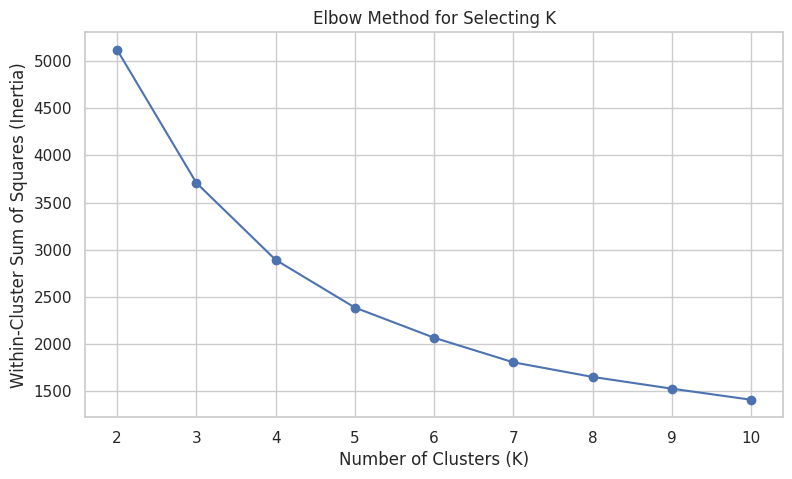

In [64]:
# Elbow Method
inertias = []
k_values = range(2, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Method for Selecting K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

## Observation — Elbow Method

The Elbow Method compares the within-cluster sum of squares for different values of K. As the number of clusters increases, inertia generally decreases.

The preferred K is a value near the point where the reduction in inertia begins to slow. This balances cluster compactness with model simplicity.

The elbow should be selected by examining the actual plotted curve. It should not be assumed in advance that a particular number of clusters is optimal.

,K,Silhouette Score
0,2,0.392760
1,3,0.339082
2,4,0.324874
3,5,0.323677
4,6,0.318513
5,7,0.302976
6,8,0.299923
8,10,0.296153
7,9,0.289365


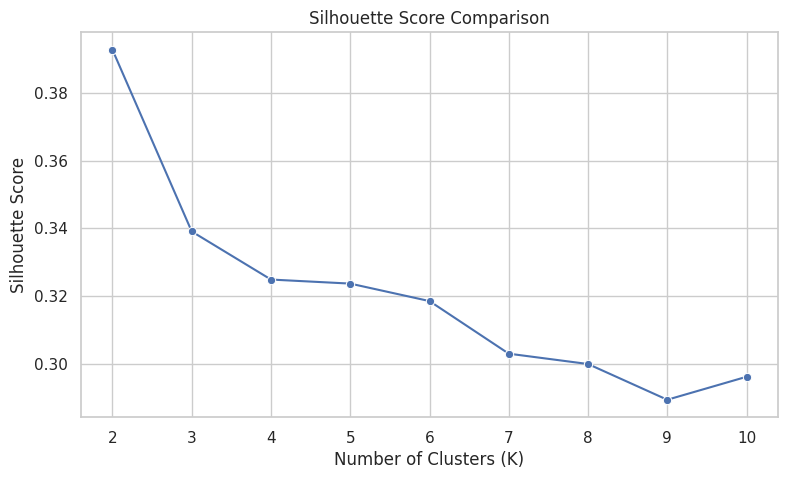

In [65]:
# Optional silhouette-score comparison
silhouette_results = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled,labels,sample_size=min(10000, len(X_scaled)),random_state=42)
    silhouette_results.append({"K": k,"Silhouette Score": score})

silhouette_df = pd.DataFrame(silhouette_results)
display(
    silhouette_df.sort_values("Silhouette Score",ascending=False)
    )
plt.figure(figsize=(9, 5))
sns.lineplot(
    data=silhouette_df,
    x="K",
    y="Silhouette Score",
    marker="o"
)
plt.title("Silhouette Score Comparison")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(range(2, 11))
plt.show()

In [66]:
# Train the K-Means model
# Change this after inspecting the Elbow Method and silhouette results.
chosen_k = 4

if chosen_k < 2 or chosen_k > 10:
    raise ValueError("Choose a K between 2 and 10.")

kmeans = KMeans(n_clusters=chosen_k,random_state=42,n_init=10)
rfm_model["Cluster"] = kmeans.fit_predict(X_scaled)
print("K-Means model trained.")
print("Chosen number of clusters:", chosen_k)
print("Cluster labels:", sorted(rfm_model["Cluster"].unique()))

cluster_silhouette = silhouette_score(
    X_scaled,
    rfm_model["Cluster"],
    sample_size=min(10000, len(rfm_model)),
    random_state=42
)

print("Silhouette score:", round(cluster_silhouette, 4))

K-Means model trained.
Chosen number of clusters: 4
Cluster labels: [np.int32(0), np.int32(1), np.int32(2), np.int32(3)]
Silhouette score: 0.3249


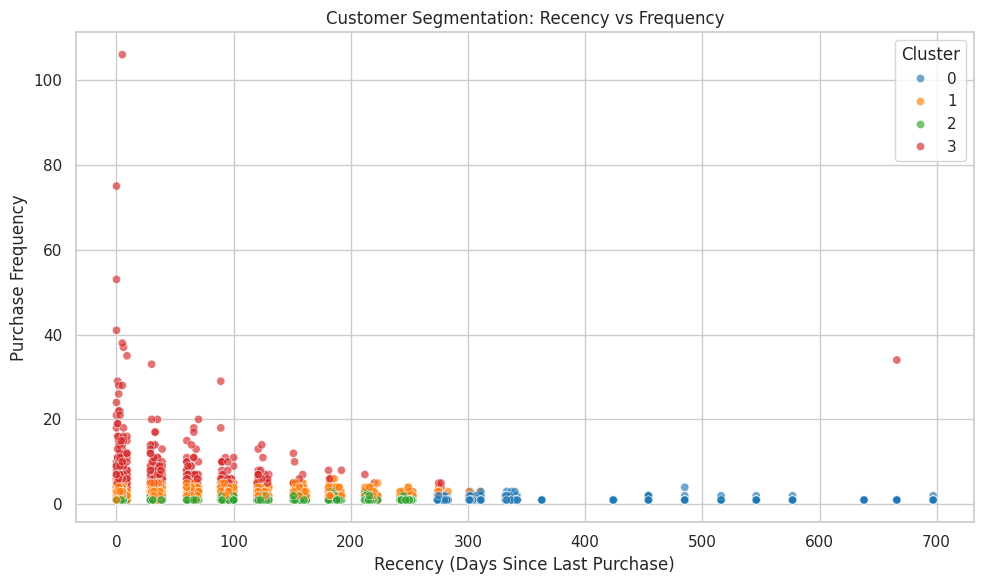

In [67]:
# Visualize customer clusters
plot_df = rfm_model.copy()
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x="Recency",
    y="Frequency",
    hue="Cluster",
    palette="tab10",
    alpha=0.65,
    s=35
)
plt.title("Customer Segmentation: Recency vs Frequency")
plt.xlabel("Recency (Days Since Last Purchase)")
plt.ylabel("Purchase Frequency")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

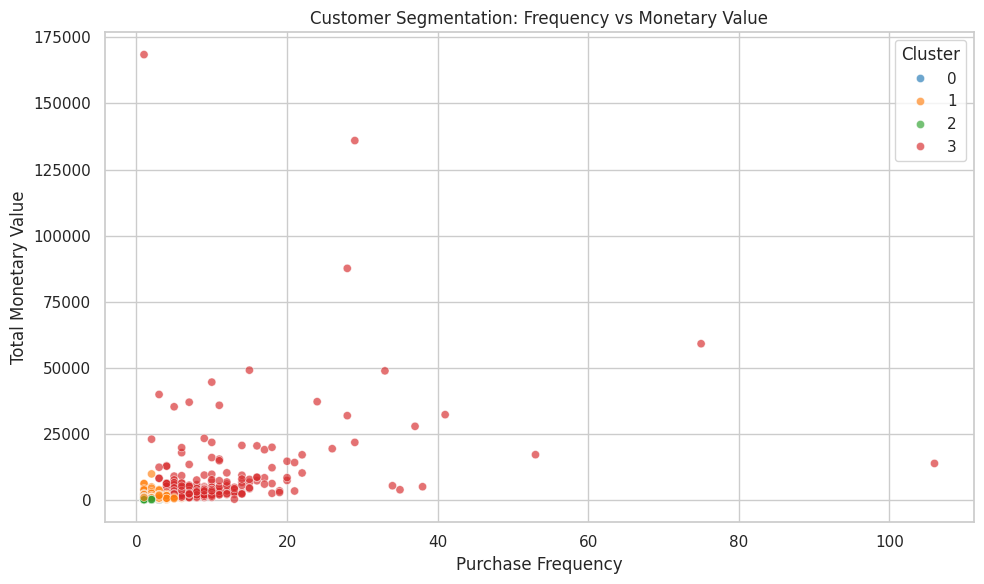

In [68]:
# Scatter plot: Frequency vs Monetary
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="tab10",
    alpha=0.65,
    s=35
)

plt.title("Customer Segmentation: Frequency vs Monetary Value")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Monetary Value")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

## Observation — Customer Cluster Scatter Plots

The scatter plots show how customers are distributed across the clusters identified by K-Means.

The Recency-versus-Frequency plot helps compare recently active customers with customers who purchase infrequently or have not purchased recently. The Frequency-versus-Monetary plot helps distinguish frequent, high-spending customers from occasional or lower-spending customers.

The actual cluster characteristics should be confirmed using the cluster profile table rather than inferred from the cluster colors alone.

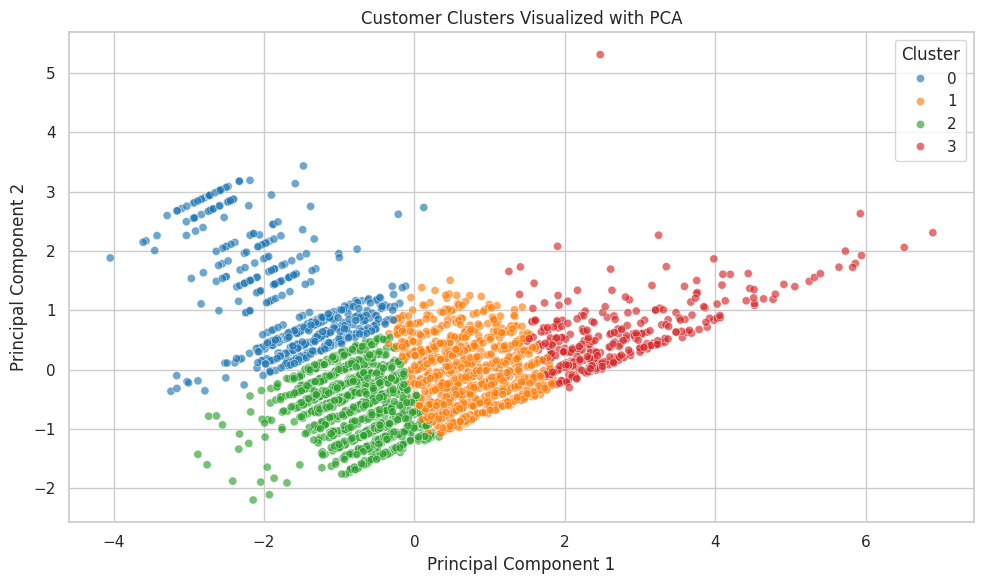

Variance explained by first two components: 91.26 %


In [69]:
# Optional third visualization using PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(pca_components,columns=["PC1", "PC2"],index=rfm_model.index)
pca_df["Cluster"] = rfm_model["Cluster"]
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.65,
    s=35
)

plt.title("Customer Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

print("Variance explained by first two components:",round(pca.explained_variance_ratio_.sum() * 100, 2),"%")

In [70]:
# Profile the customer segments
cluster_profile = rfm_model.groupby("Cluster").agg(
    CustomerCount=("Recency", "size"),
    AvgRecency=("Recency", "mean"),
    AvgFrequency=("Frequency", "mean"),
    AvgMonetary=("Monetary", "mean")
).round(2)

cluster_profile["CustomerPercentage"] = (
    cluster_profile["CustomerCount"]
    / cluster_profile["CustomerCount"].sum()
    * 100
).round(2)

cluster_profile = cluster_profile.sort_values("AvgMonetary",ascending=False)
display(cluster_profile)

,CustomerCount,AvgRecency,AvgFrequency,AvgMonetary,CustomerPercentage
Cluster,,,,,
3,347,50.10,9.44,6543.19,11.58
1,1020,95.90,2.75,1085.46,34.03
0,514,391.51,1.14,340.92,17.15
2,1116,131.14,1.16,280.09,37.24


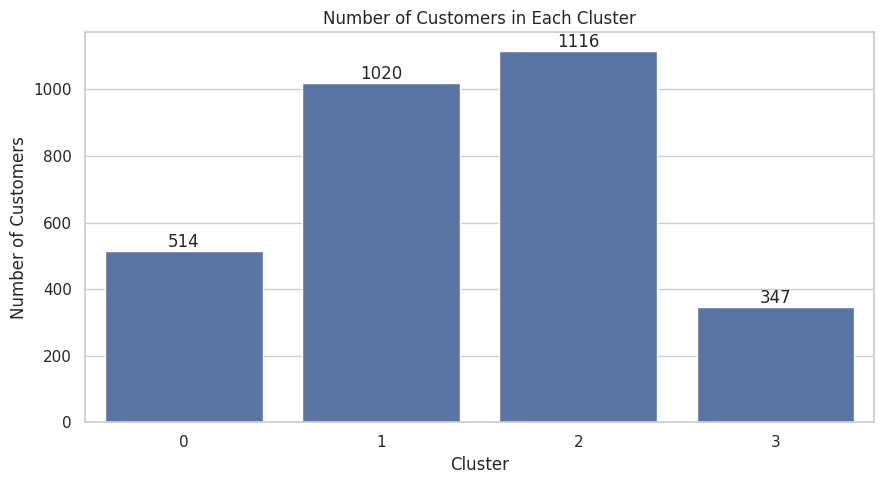

In [71]:
# Bar chart: Number of customers per cluster
cluster_counts = (
    rfm_model["Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="CustomerCount")
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=cluster_counts,x="Cluster",y="CustomerCount")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

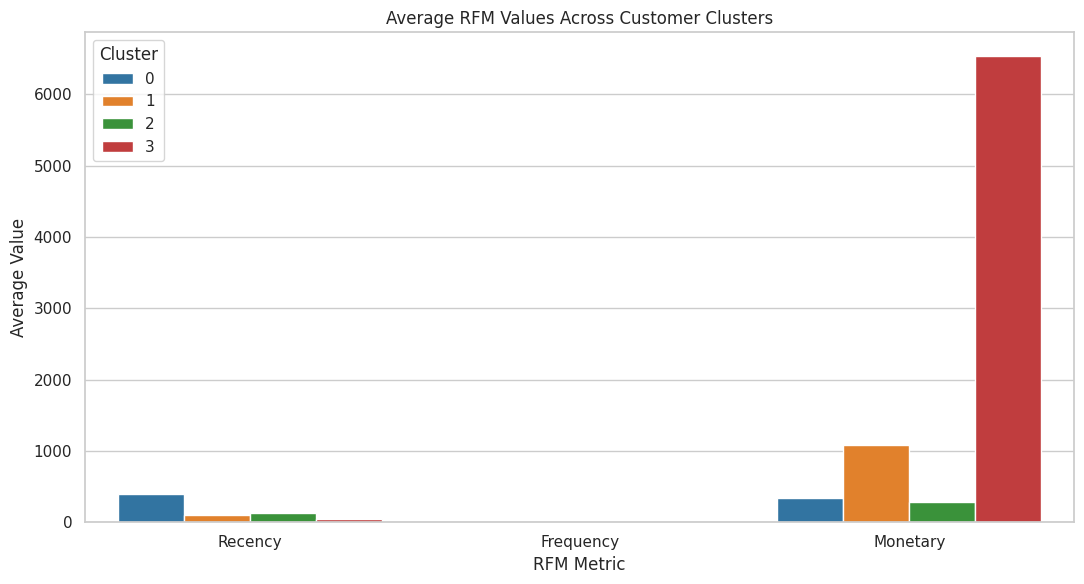

In [72]:
# Compare average RFM values by cluster
profile_long = (
    rfm_model.groupby("Cluster")[
        ["Recency", "Frequency", "Monetary"]].mean().reset_index().melt(id_vars="Cluster",var_name="Metric",value_name="AverageValue")
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=profile_long,
    x="Metric",
    y="AverageValue",
    hue="Cluster",
    palette="tab10"
)

plt.title("Average RFM Values Across Customer Clusters")
plt.xlabel("RFM Metric")
plt.ylabel("Average Value")
plt.tight_layout()
plt.show()

## Observation — Cluster Profiles

The cluster profile table summarizes the number of customers and their average recency, purchase frequency, and monetary value.

A segment with lower average recency and higher frequency and spending may represent valuable, active customers. A segment with higher recency may contain customers who have not purchased recently. Other segments may represent occasional buyers or customers with lower historical spending.

These interpretations must be assigned using the actual values in the cluster profile table. Cluster numbers are arbitrary identifiers, not customer rankings.

In [73]:
# Assign descriptive names based on cluster profiles

segment_names = {
    3: "High-Value, Frequent Customers",
    1: "Regular / Developing Customers",
    0: "Dormant / Inactive Customers",
    2: "Low-Spending, Occasional Customers"
}

cluster_profile["SegmentName"] = (
    cluster_profile.index.map(segment_names)
)

display(cluster_profile)

,CustomerCount,AvgRecency,AvgFrequency,AvgMonetary,CustomerPercentage,SegmentName
Cluster,,,,,,
3,347,50.10,9.44,6543.19,11.58,"High-Value, Frequent Customers"
1,1020,95.90,2.75,1085.46,34.03,Regular / Developing Customers
0,514,391.51,1.14,340.92,17.15,Dormant / Inactive Customers
2,1116,131.14,1.16,280.09,37.24,"Low-Spending, Occasional Customers"


In [74]:
# Attach segment names to customer records
segment_names = cluster_profile["SegmentName"].to_dict()
rfm_model["SegmentName"] = rfm_model["Cluster"].map(segment_names)

display(rfm_model[
        [
            "Recency",
            "Frequency",
            "Monetary",
            "Cluster",
            "SegmentName"
        ]].head(15)
)

,Recency,Frequency,Monetary,Cluster,SegmentName
CustomerID,,,,,
12347.0,95,5,2540.29,3,"High-Value, Frequent Customers"
12348.0,220,1,367.00,2,"Low-Spending, Occasional Customers"
12350.0,311,1,334.40,0,Dormant / Inactive Customers
12352.0,274,3,1296.38,1,Regular / Developing Customers
12355.0,96,1,459.40,2,"Low-Spending, Occasional Customers"
12356.0,128,1,481.46,2,"Low-Spending, Occasional Customers"
12357.0,182,1,6207.67,1,Regular / Developing Customers
12358.0,3,2,1168.06,1,Regular / Developing Customers
12359.0,9,3,3495.73,1,Regular / Developing Customers


In [75]:
# Marketing recommendations by segment

marketing_actions = {
    "High-Value, Frequent Customers":
        "Reward loyalty with exclusive benefits, early access, and personalized offers.",

    "Regular / Developing Customers":
        "Use personalized product recommendations and modest incentives to encourage repeat purchases.",

    "Dormant / Inactive Customers":
        "Run targeted win-back campaigns and monitor whether customers return.",

    "Low-Spending, Occasional Customers":
        "Encourage repeat purchases through complementary products and relevant offers."
}

cluster_profile["MarketingRecommendation"] = (
    cluster_profile["SegmentName"].map(marketing_actions)
)

display(cluster_profile)

,CustomerCount,AvgRecency,AvgFrequency,AvgMonetary,CustomerPercentage,SegmentName,MarketingRecommendation
Cluster,,,,,,,
3,347,50.10,9.44,6543.19,11.58,"High-Value, Frequent Customers","Reward loyalty with exclusive benefits, early ..."
1,1020,95.90,2.75,1085.46,34.03,Regular / Developing Customers,Use personalized product recommendations and m...
0,514,391.51,1.14,340.92,17.15,Dormant / Inactive Customers,Run targeted win-back campaigns and monitor wh...
2,1116,131.14,1.16,280.09,37.24,"Low-Spending, Occasional Customers",Encourage repeat purchases through complementa...


## Marketing Strategy

Different customer segments require different marketing approaches. Active, high-value customers may respond well to loyalty benefits, while customers with high historical spending but high recency may benefit from carefully designed re-engagement campaigns.

Occasional buyers may respond to relevant product recommendations and incentives for a repeat purchase. Marketing actions should be evaluated using campaign conversion rates, incremental revenue, and profit rather than customer spending alone.

The recommendations in this notebook are initial strategies derived from historical purchasing behaviour; their effectiveness should be tested before implementation.

In [76]:
# Key findings and conclusion
print("=" * 60)
print("CUSTOMER SEGMENTATION SUMMARY")
print("=" * 60)
print("Total customers analysed:", len(rfm_model))
print("Number of clusters:", chosen_k)
print("Total historical purchase value:",round(rfm_model["Monetary"].sum(), 2))

print("\nCustomer count by segment:")
display(rfm_model["SegmentName"].value_counts().rename_axis("Segment").reset_index(name="Customers"))

print("\nCluster profile:")
display(cluster_profile)

CUSTOMER SEGMENTATION SUMMARY
Total customers analysed: 2997
Number of clusters: 4
Total historical purchase value: 3865463.08

Customer count by segment:


,Segment,Customers
0,"Low-Spending, Occasional Customers",1116
1,Regular / Developing Customers,1020
2,Dormant / Inactive Customers,514
3,"High-Value, Frequent Customers",347



Cluster profile:


,CustomerCount,AvgRecency,AvgFrequency,AvgMonetary,CustomerPercentage,SegmentName,MarketingRecommendation
Cluster,,,,,,,
3,347,50.10,9.44,6543.19,11.58,"High-Value, Frequent Customers","Reward loyalty with exclusive benefits, early ..."
1,1020,95.90,2.75,1085.46,34.03,Regular / Developing Customers,Use personalized product recommendations and m...
0,514,391.51,1.14,340.92,17.15,Dormant / Inactive Customers,Run targeted win-back campaigns and monitor wh...
2,1116,131.14,1.16,280.09,37.24,"Low-Spending, Occasional Customers",Encourage repeat purchases through complementa...


# Conclusion

This project applied Exploratory Data Analysis and K-Means clustering to the UCI Online Retail dataset to identify groups of customers with different purchasing behaviours.

The analysis calculated Recency, Frequency, and Monetary (RFM) features, standardized the clustering inputs, examined candidate cluster counts using the Elbow Method and silhouette scores, and applied K-Means to group customers.

The resulting customer segments were profiled using their average recency, purchase frequency, and monetary value. Scatter plots, cluster-size charts, and a profile table helped interpret the differences between segments.

## Actionable Business Recommendations

1. **Retain valuable customers:** Offer appropriate loyalty benefits and personalized recommendations to customers who purchase frequently and contribute high historical revenue.

2. **Re-engage inactive customers:** Identify customers with high recency values and test targeted win-back campaigns. Measure whether these campaigns generate incremental profit.

3. **Increase repeat purchases:** Encourage occasional customers to return with relevant product recommendations, complementary offers, and loyalty incentives.

4. **Evaluate campaign performance:** Track conversion rates, incremental revenue, and profit for each customer segment to determine which strategies work best.

## Limitations

The segmentation is based on historical transactions and positive purchase records. Cancelled transactions and non-positive quantities were excluded from the RFM calculations. Historical monetary value is used as a proxy for customer value, not as a prediction of future customer lifetime value.

K-Means results depend on feature preparation and the selected number of clusters. The segments and marketing strategies should be reviewed periodically as customer behaviour changes.

Overall, this project demonstrates how customer transaction data can be transformed into actionable customer segments using Python and machine learning.

In [77]:
# Export your results
# Save RFM values and assigned cluster labels
customer_output = rfm_model.reset_index()

customer_output.to_csv("Customer_Segmentation_Results.csv",index=False)

# Save the cluster summary
cluster_profile.to_csv("Customer_Segment_Profile.csv",index=True)

print("Files saved successfully:")
print("1. Customer_Segmentation_Results.csv")
print("2. Customer_Segment_Profile.csv")

Files saved successfully:
1. Customer_Segmentation_Results.csv
2. Customer_Segment_Profile.csv


In [78]:
# Download the output files
from google.colab import files

files.download("Customer_Segmentation_Results.csv")
files.download("Customer_Segment_Profile.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>